In [136]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import colorsys
from matplotlib.ticker import PercentFormatter, MultipleLocator


# ============================================================
# Generate vivid distinct colors
# ============================================================
def generate_vivid_colors(n):
    """
    Generate n visually distinct vivid colors using HSV space.
    """
    colors = []
    for i in range(n):
        hue = i / n
        saturation = 0.9
        value = 0.9
        rgb = colorsys.hsv_to_rgb(hue, saturation, value)
        colors.append(rgb)
    return colors


# ============================================================
# Plot multiple result folders (publication style)
# ============================================================
def plot_multiple_result_dirs(
    dir_list,
    chunk_sizes,
    max_event=650,
    title=None
):

    dir_list = [Path(d) for d in dir_list]

    # ---- chunk size handling ----
    if isinstance(chunk_sizes, int):
        chunk_sizes = [chunk_sizes] * len(dir_list)

    if len(chunk_sizes) != len(dir_list):
        raise ValueError("chunk_sizes must match number of directories")

    colors = generate_vivid_colors(len(dir_list))

    plt.figure(figsize=(10, 6))

    # ========================================================
    # Loop over result folders
    # ========================================================
    for dir_idx, result_dir in enumerate(dir_list):

        color = colors[dir_idx]
        chunk_size = chunk_sizes[dir_idx]
        dir_name = result_dir.name

        for json_file in result_dir.glob("*.json"):

            try:
                with open(json_file, "r") as f:
                    data = json.load(f)

                n = np.array(data["n"])
                avg_eer = np.array(data["avg_eer"])

                events = n * chunk_size

                mask = events <= max_event
                events = events[mask]
                avg_eer = avg_eer[mask]

                label = f"{dir_name} - {json_file.stem}"

                plt.plot(
                    events,
                    avg_eer,
                    linestyle="-",
                    linewidth=2.5,
                    marker="o",
                    markersize=5,
                    color=color,
                    alpha=0.95,
                    label=label
                )

            except Exception as e:
                print(f"[ERROR] Failed to process {json_file}: {e}")

    # ========================================================
    # Axis styling
    # ========================================================

    ax = plt.gca()

    # ----- Y axis start from 0 -----
    ax.set_ylim(bottom=0)

    # ----- tick every 0.5% -----
    ax.yaxis.set_major_locator(MultipleLocator(0.005))

    # ----- show percentage -----
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))

    # ========================================================
    # Labels
    # ========================================================

    plt.xlabel("Events (n × chunk_size)", fontsize=13)
    plt.ylabel("Average EER (%)", fontsize=13)

    if title:
        plt.title(title, fontsize=14, weight="bold")
    else:
        plt.title("Multiple Result Comparison", fontsize=14, weight="bold")

    plt.grid(True, linestyle="--", alpha=0.4)

    plt.legend(
        fontsize=9,
        ncol=2,
        frameon=False
    )

    plt.tight_layout()
    plt.show()

## Balabit Protocol1

## CNN

**SRP**

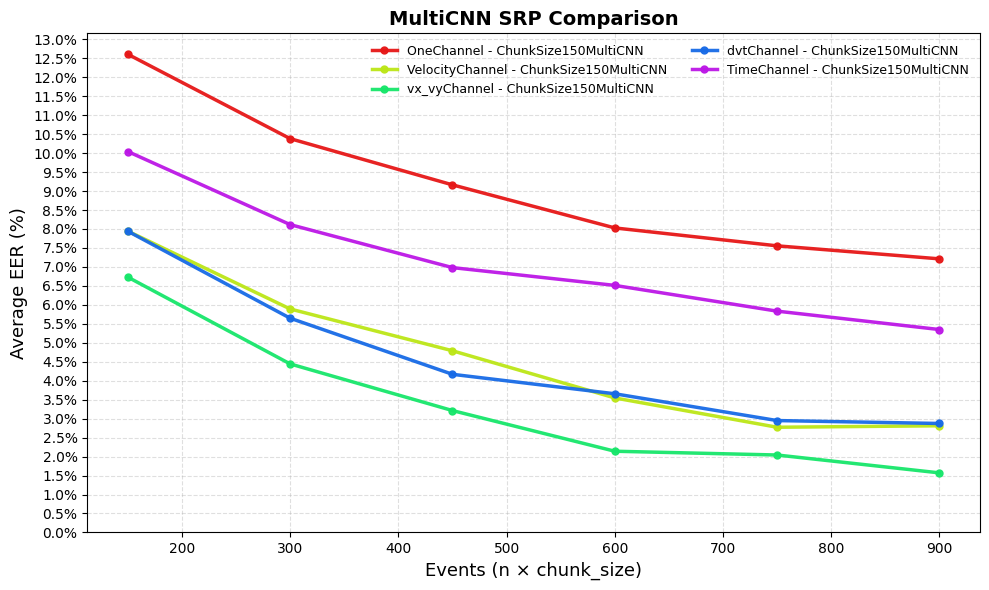

In [137]:
dir_list = ["Results/BalabitProtocol1/CNN/SRP/OneChannel","Results/BalabitProtocol1/CNN/SRP/VelocityChannel",
"Results/BalabitProtocol1/CNN/SRP/vx_vyChannel","Results/BalabitProtocol1/CNN/SRP/dvtChannel","Results/BalabitProtocol1/CNN/SRP/TimeChannel"]
plot_multiple_result_dirs(
    dir_list,
    max_event=1000,
    title="MultiCNN SRP Comparison",
    chunk_sizes=150
)

In [138]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/BalabitProtocol1/CNN/SRP/per-userVelocityChannel/ChunkSize150MultiCNN.json"
json_cdf = "Results/BalabitProtocol1/CNN/SRP/per-uservx_vyChannel/ChunkSize150MultiCNN.json"

n_targets = [i+1 for i in range(4)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="Velocity",
    label_b="vx_vy",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (Velocity),Mean EER (vx_vy),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,Velocity vs vx_vy,1,10,7.94,6.73,1.21,0.105469,False
1,Velocity vs vx_vy,2,10,5.89,4.44,1.45,0.019531,True
2,Velocity vs vx_vy,3,10,4.79,3.21,1.58,0.011719,True
3,Velocity vs vx_vy,4,10,3.55,2.14,1.41,0.074219,False


In [139]:
from statistics_things.compare_sota import compare_sota_vs_ours, pretty_print

res = compare_sota_vs_ours(
    json_path="Results/BalabitProtocol1/CNN/SRP/per-uservx_vyChannel/ChunkSize150MultiCNN.json",
    sota_csv_path="Results/SOTA/Balabit.csv"
)

pretty_print(res)


==== DEBUG ====
OURS count: 10
SOTA count: 10
OURS users: ['user12', 'user15', 'user16', 'user20', 'user21', 'user23', 'user29', 'user35', 'user7', 'user9']
SOTA users: ['user12', 'user15', 'user16', 'user20', 'user21', 'user23', 'user29', 'user35', 'user7', 'user9']

Paired users: ['user12', 'user15', 'user16', 'user20', 'user21', 'user23', 'user29', 'user35', 'user7', 'user9']
Paired count: 10
After removing ties: 10

SOTA vs Ours (600-event)
Users: 10
Ours : 2.14%
SOTA : 4.98%

p-value: 0.001953
Significant: True

 Ours is better


**XYPlot**

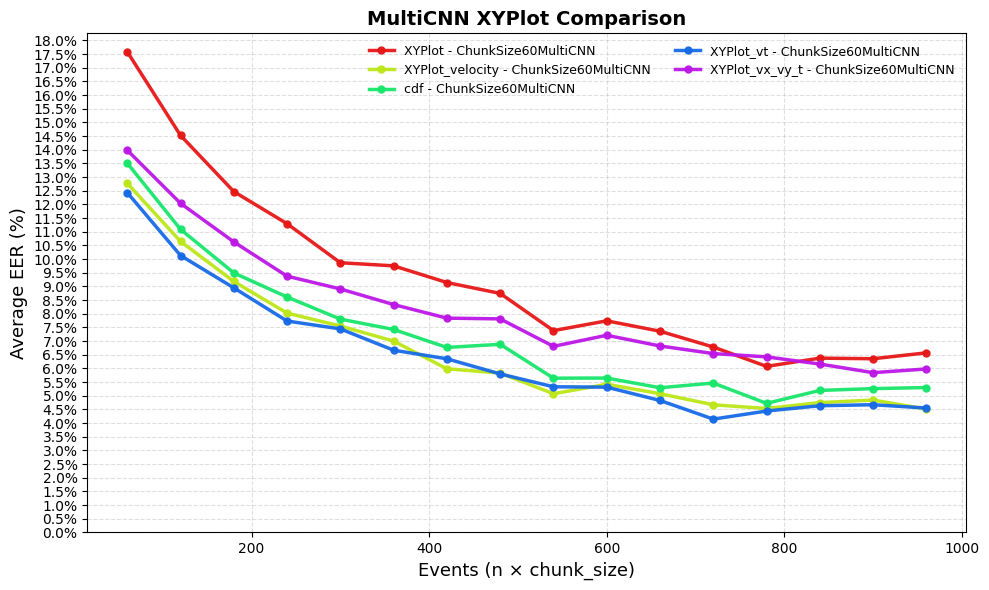

In [140]:
dir_list = ["Results/Protocol1/Scratch_MultiCNN/XYPlot/XYPlot","Results/Protocol1/Scratch_MultiCNN/XYPlot/XYPlot_velocity",
"Results/Protocol1/Scratch_MultiCNN/XYPlot/cdf","Results/Protocol1/Scratch_MultiCNN/XYPlot/XYPlot_vt",
"Results/Protocol1/Scratch_MultiCNN/XYPlot/XYPlot_vx_vy_t"]
plot_multiple_result_dirs(
    dir_list,
    max_event=1000,
    title="MultiCNN XYPlot Comparison",
    chunk_sizes=60
)

In [141]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/Protocol1/Scratch_MultiCNN/XYPlot/per-userXYPlot_vx_vy_t/ChunkSize60MultiCNN.json"
json_cdf = "Results/Protocol1/Scratch_MultiCNN/XYPlot/per-userXYPlot_velocity/ChunkSize60MultiCNN.json"

n_targets = [i+1 for i in range(10)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="vx_vy",
    label_b="velocity",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (vx_vy),Mean EER (velocity),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,vx_vy vs velocity,1,10,13.98,12.77,1.21,0.019531,True
1,vx_vy vs velocity,2,10,12.04,10.65,1.39,0.005859,True
2,vx_vy vs velocity,3,10,10.63,9.18,1.45,0.037109,True
3,vx_vy vs velocity,4,10,9.38,8.02,1.35,0.054688,False
4,vx_vy vs velocity,5,10,8.91,7.55,1.36,0.097656,False
5,vx_vy vs velocity,6,10,8.34,7.00,1.34,0.359375,False
6,vx_vy vs velocity,7,10,7.84,5.99,1.85,0.011719,True
7,vx_vy vs velocity,8,10,7.81,5.83,1.98,0.011719,True
8,vx_vy vs velocity,9,10,6.81,5.08,1.73,0.027344,True
9,vx_vy vs velocity,10,10,7.21,5.42,1.79,0.019531,True


## ViT

**SRP**

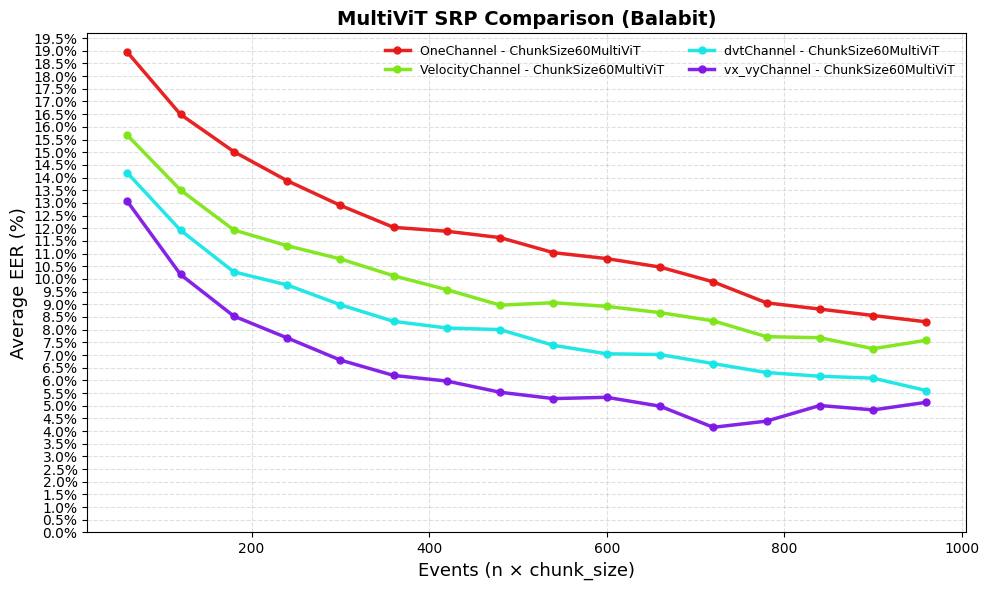

In [142]:
dir_list = ["Results/Protocol1/Scratch_MultiViT/SRP/OneChannel","Results/Protocol1/Scratch_MultiViT/SRP/VelocityChannel",
            "Results/Protocol1/Scratch_MultiViT/SRP/dvtChannel", "Results/Protocol1/Scratch_MultiViT/SRP/vx_vyChannel"]
plot_multiple_result_dirs(
    dir_list,
    max_event=1000,
    title="MultiViT SRP Comparison (Balabit)",
    chunk_sizes=60
)

In [143]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/Protocol1/Scratch_MultiViT/SRP/per-userdvtChannel/ChunkSize60MultiViT.json"
json_cdf = "Results/Protocol1/Scratch_MultiViT/SRP/per-uservx_vyChannel/ChunkSize60MultiViT.json"

n_targets = [i+1 for i in range(10)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="dvt",
    label_b="vx_vy",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (dvt),Mean EER (vx_vy),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,dvt vs vx_vy,1,10,14.19,13.07,1.12,0.037109,True
1,dvt vs vx_vy,2,10,11.92,10.18,1.75,0.009766,True
2,dvt vs vx_vy,3,10,10.28,8.53,1.74,0.013672,True
3,dvt vs vx_vy,4,10,9.76,7.68,2.09,0.003906,True
4,dvt vs vx_vy,5,10,8.98,6.80,2.18,0.007812,True
5,dvt vs vx_vy,6,10,8.33,6.19,2.13,0.054688,False
6,dvt vs vx_vy,7,10,8.07,5.97,2.09,0.019531,True
7,dvt vs vx_vy,8,10,8.00,5.53,2.47,0.019531,True
8,dvt vs vx_vy,9,10,7.38,5.28,2.10,0.128906,False
9,dvt vs vx_vy,10,10,7.05,5.33,1.72,0.164062,False


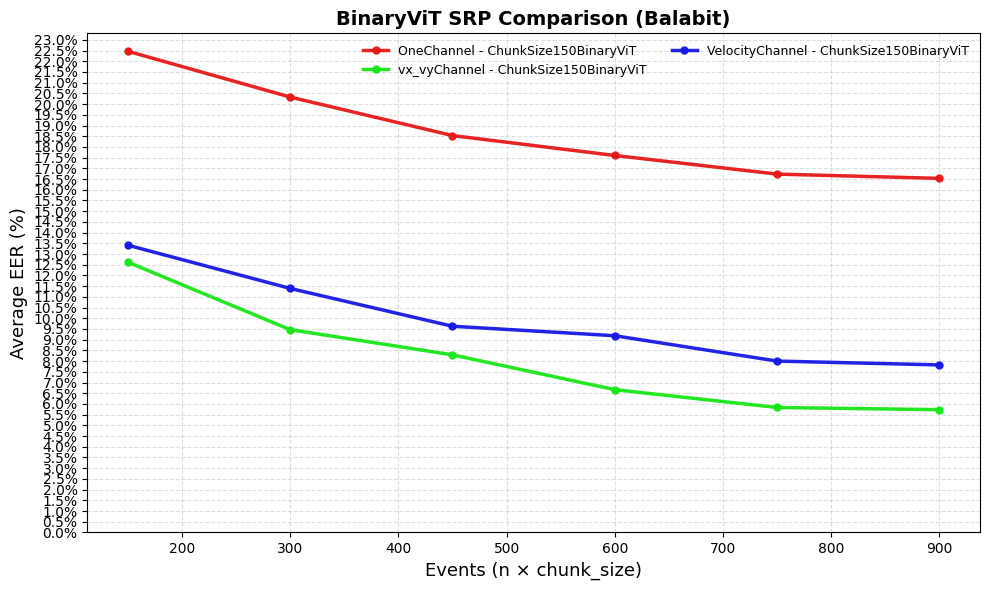

In [144]:
dir_list = ["Results/BalabitProtocol1/BinaryViT/SRP/OneChannel","Results/BalabitProtocol1/BinaryViT/SRP/vx_vyChannel",
            "Results/BalabitProtocol1/BinaryViT/SRP/VelocityChannel"]
plot_multiple_result_dirs(
    dir_list,
    max_event=1000,
    title="BinaryViT SRP Comparison (Balabit)",
    chunk_sizes=150
)

In [145]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/BalabitProtocol1/BinaryViT/SRP/per-userVelocityChannel/ChunkSize150BinaryViT.json"
json_cdf = "Results/BalabitProtocol1/BinaryViT/SRP/per-uservx_vyChannel/ChunkSize150BinaryViT.json"

n_targets = [i+1 for i in range(4)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="dvt",
    label_b="vx_vy",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (dvt),Mean EER (vx_vy),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,dvt vs vx_vy,1,10,13.41,12.62,0.79,0.375000,False
1,dvt vs vx_vy,2,10,11.39,9.47,1.92,0.019531,True
2,dvt vs vx_vy,3,10,9.63,8.29,1.34,0.074219,False
3,dvt vs vx_vy,4,10,9.19,6.67,2.52,0.007812,True


In [146]:
from statistics_things.compare_sota import compare_sota_vs_ours, pretty_print

res = compare_sota_vs_ours(
    json_path="Results/BalabitProtocol1/BinaryViT/SRP/per-uservx_vyChannel/ChunkSize150BinaryViT.json",
    sota_csv_path="Results/SOTA/Balabit.csv"
)

pretty_print(res)


==== DEBUG ====
OURS count: 10
SOTA count: 10
OURS users: ['user12', 'user15', 'user16', 'user20', 'user21', 'user23', 'user29', 'user35', 'user7', 'user9']
SOTA users: ['user12', 'user15', 'user16', 'user20', 'user21', 'user23', 'user29', 'user35', 'user7', 'user9']

Paired users: ['user12', 'user15', 'user16', 'user20', 'user21', 'user23', 'user29', 'user35', 'user7', 'user9']
Paired count: 10
After removing ties: 10

SOTA vs Ours (600-event)
Users: 10
Ours : 6.67%
SOTA : 4.98%

p-value: 0.903320
Significant: False

 SOTA is better


**XYPlot**

## Balabit Protocol2

## ChaoShen

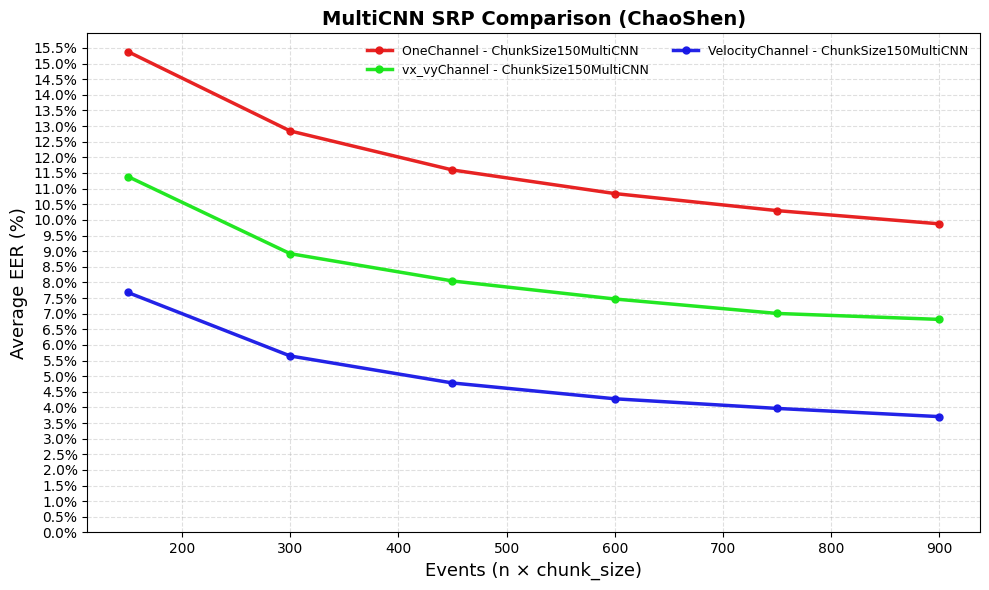

In [147]:
dir_list = ["Results/ChaoShen/CNN/SRP/OneChannel", "Results/ChaoShen/CNN/SRP/vx_vyChannel", "Results/ChaoShen/CNN/SRP/VelocityChannel"]
plot_multiple_result_dirs(
    dir_list,
    max_event=1000,
    title="MultiCNN SRP Comparison (ChaoShen)",
    chunk_sizes=150
)

In [148]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/ChaoShen/CNN/SRP/per-uservx_vyChannel/ChunkSize150MultiCNN.json"
json_cdf = "Results/ChaoShen/CNN/SRP/per-userVelocityChannel/ChunkSize150MultiCNN.json"

n_targets = [i+1 for i in range(4)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="Velocity",
    label_b="vx_vy",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (Velocity),Mean EER (vx_vy),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,Velocity vs vx_vy,1,28,11.39,7.68,3.71,2.235174e-08,True
1,Velocity vs vx_vy,2,28,8.92,5.65,3.27,2.458692e-07,True
2,Velocity vs vx_vy,3,28,8.05,4.78,3.26,3.203750e-07,True
3,Velocity vs vx_vy,4,28,7.47,4.28,3.19,6.556511e-07,True


In [149]:
from statistics_things.compare_sota import compare_sota_vs_ours, pretty_print

res = compare_sota_vs_ours(
    json_path="Results/ChaoShen/CNN/SRP/per-userVelocityChannel/ChunkSize150MultiCNN.json",
    sota_csv_path="Results/SOTA/ChaoShen.csv",

    ours_offset=+1, 
    sota_offset=0
)

pretty_print(res)


==== DEBUG ====
OURS count: 28
SOTA count: 28
OURS users: ['user1', 'user10', 'user11', 'user12', 'user13', 'user14', 'user15', 'user16', 'user17', 'user18', 'user19', 'user2', 'user20', 'user21', 'user22', 'user23', 'user24', 'user25', 'user26', 'user27', 'user28', 'user3', 'user4', 'user5', 'user6', 'user7', 'user8', 'user9']
SOTA users: ['user1', 'user10', 'user11', 'user12', 'user13', 'user14', 'user15', 'user16', 'user17', 'user18', 'user19', 'user2', 'user20', 'user21', 'user22', 'user23', 'user24', 'user25', 'user26', 'user27', 'user28', 'user3', 'user4', 'user5', 'user6', 'user7', 'user8', 'user9']

Paired users: ['user1', 'user10', 'user11', 'user12', 'user13', 'user14', 'user15', 'user16', 'user17', 'user18', 'user19', 'user2', 'user20', 'user21', 'user22', 'user23', 'user24', 'user25', 'user26', 'user27', 'user28', 'user3', 'user4', 'user5', 'user6', 'user7', 'user8', 'user9']
Paired count: 28
After removing ties: 28

SOTA vs Ours (600-event)
Users: 28
Ours : 4.28%
SOTA : 5

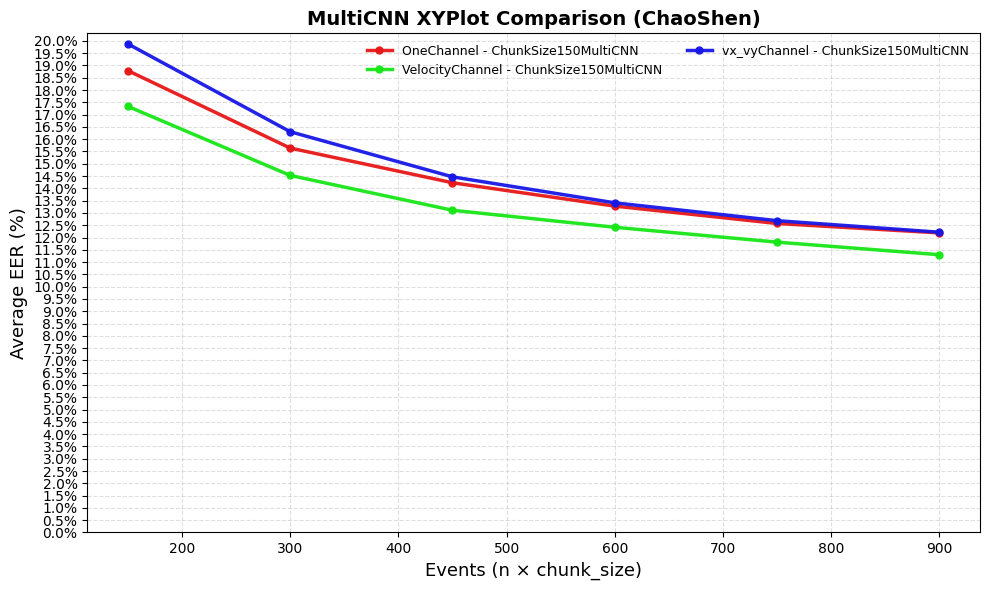

In [150]:
dir_list = ["Results/ChaoShen/CNN/XYPlot/OneChannel","Results/ChaoShen/CNN/XYPlot/VelocityChannel","Results/ChaoShen/CNN/XYPlot/vx_vyChannel"]
plot_multiple_result_dirs(
    dir_list,
    max_event=1000,
    title="MultiCNN XYPlot Comparison (ChaoShen)",
    chunk_sizes=150
)

In [151]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/ChaoShen/CNN/XYPlot/per-userOneChannel/ChunkSize150MultiCNN.json"
json_cdf = "Results/ChaoShen/CNN/XYPlot/per-userVelocityChannel/ChunkSize150MultiCNN.json"

n_targets = [i+1 for i in range(4)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="Basline",
    label_b="Velocity",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (Basline),Mean EER (Velocity),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,Basline vs Velocity,1,28,18.79,17.34,1.45,0.000003,True
1,Basline vs Velocity,2,28,15.64,14.53,1.11,0.000583,True
2,Basline vs Velocity,3,28,14.23,13.11,1.12,0.003739,True
3,Basline vs Velocity,4,28,13.28,12.42,0.86,0.015633,True


In [152]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/ChaoShen/CNN/XYPlot/per-uservx_vyChannel/ChunkSize150MultiCNN.json"
json_cdf = "Results/ChaoShen/CNN/XYPlot/per-userOneChannel/ChunkSize150MultiCNN.json"

n_targets = [i+1 for i in range(4)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="vxvy",
    label_b="Baseline",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (vxvy),Mean EER (Baseline),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,vxvy vs Baseline,1,28,19.88,18.79,1.09,0.006060,True
1,vxvy vs Baseline,2,28,16.30,15.64,0.67,0.066240,False
2,vxvy vs Baseline,3,28,14.47,14.23,0.24,0.305226,False
3,vxvy vs Baseline,4,28,13.41,13.28,0.13,0.629528,False


## DFL

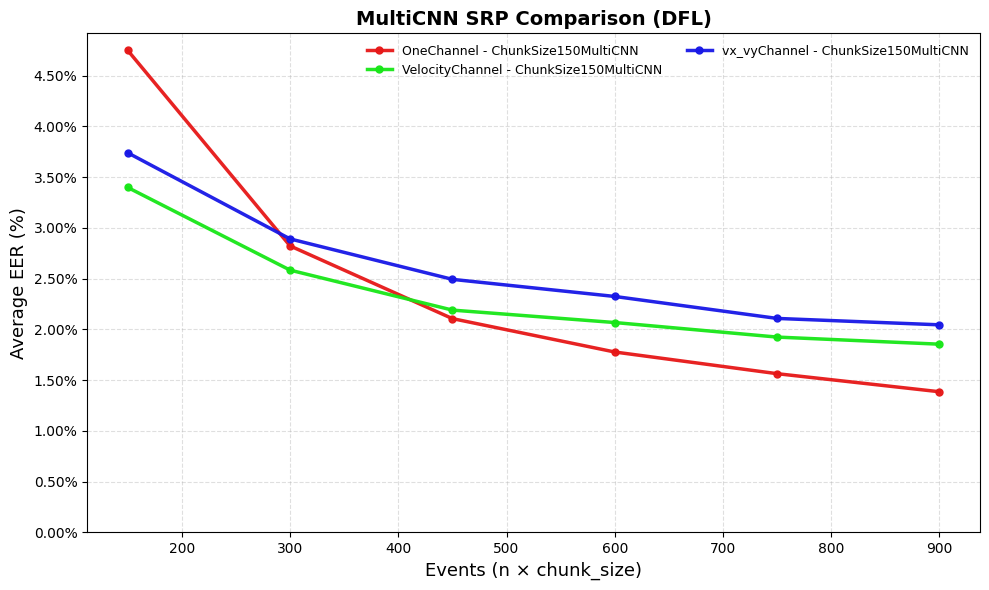

In [153]:
dir_list = ["Results/DFL/CNN/SRP/OneChannel","Results/DFL/CNN/SRP/VelocityChannel","Results/DFL/CNN/SRP/vx_vyChannel"]
plot_multiple_result_dirs(
    dir_list,
    max_event=1000,
    title="MultiCNN SRP Comparison (DFL)",
    chunk_sizes=150
)

In [154]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/DFL/CNN/SRP/per-userOneChannel/ChunkSize150MultiCNN.json"
json_cdf = "Results/DFL/CNN/SRP/per-userVelocityChannel/ChunkSize150MultiCNN.json"

n_targets = [i+1 for i in range(4)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="baselin",
    label_b="velocity",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (baselin),Mean EER (velocity),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,baselin vs velocity,1,21,4.75,3.40,1.35,0.001374,True
1,baselin vs velocity,2,21,2.82,2.58,0.24,0.103214,False
2,baselin vs velocity,3,21,2.11,2.19,0.08,0.157134,False
3,baselin vs velocity,4,21,1.78,2.07,0.29,0.320457,False


In [155]:
from statistics_things.compare_sota import compare_sota_vs_ours, pretty_print

res = compare_sota_vs_ours(
    json_path="Results/DFL/CNN/SRP/per-userOneChannel/ChunkSize150MultiCNN.json",
    sota_csv_path="Results/SOTA/DFL.csv",

    ours_offset=+1, 
    sota_offset=0
)

pretty_print(res)


==== DEBUG ====
OURS count: 21
SOTA count: 21
OURS users: ['user1', 'user10', 'user11', 'user12', 'user13', 'user14', 'user15', 'user16', 'user17', 'user18', 'user19', 'user2', 'user20', 'user21', 'user3', 'user4', 'user5', 'user6', 'user7', 'user8', 'user9']
SOTA users: ['user1', 'user10', 'user11', 'user12', 'user13', 'user14', 'user15', 'user16', 'user17', 'user18', 'user19', 'user2', 'user20', 'user21', 'user3', 'user4', 'user5', 'user6', 'user7', 'user8', 'user9']

Paired users: ['user1', 'user10', 'user11', 'user12', 'user13', 'user14', 'user15', 'user16', 'user17', 'user18', 'user19', 'user2', 'user20', 'user21', 'user3', 'user4', 'user5', 'user6', 'user7', 'user8', 'user9']
Paired count: 21
After removing ties: 21

SOTA vs Ours (600-event)
Users: 21
Ours : 1.78%
SOTA : 2.2%

p-value: 0.078567
Significant: False

 Ours is better
